# Attack Stealthiness vs Efficacy

In adversarial machine learning, there is an inherent trade-off between an attack's **efficacy** (Attack Success Rate - ASR) and its **stealthiness** (perceptual distortion, typically measured via the $L_2$ norm).

An optimal attack is highly efficacious but requires minimal perturbation, making it invisible to the human eye. In this notebook, we visualize this trade-off using a scatter plot.
* **Ideal Zone:** Top-Left (High ASR, Low $L_2$ distortion). Algorithms like DeepFool are designed to find this optimal minimal perturbation.
* **Brute Force Zone:** Top-Right (High ASR, High $L_2$ distortion). Algorithms like FGSM often rely on larger, more visible noise to guarantee success.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.lines as mlines
import plotly.express as px

In [2]:
# Load the aggregated metrics
try:
    df = pd.read_csv('robustness_metrics.csv')
except FileNotFoundError:
    print("Error: 'robustness_metrics.csv' not found.")

# Filter out the Baseline (as it has 0 perturbation and 0 ASR)
df_attacks = df[df['Attack'] != 'Baseline'].copy()

# Define consistent colors and markers
model_colors = {'EfficientNetB0': '#2ca02c', 'InceptionV3': '#1f77b4', 'MobileNetV2': '#ff7f0e'}
attack_markers = {'FGSM': 'o', 'PGD': 's', 'DeepFool': '^', 'C&W': 'D', 'T-IFGSM': 'v'}

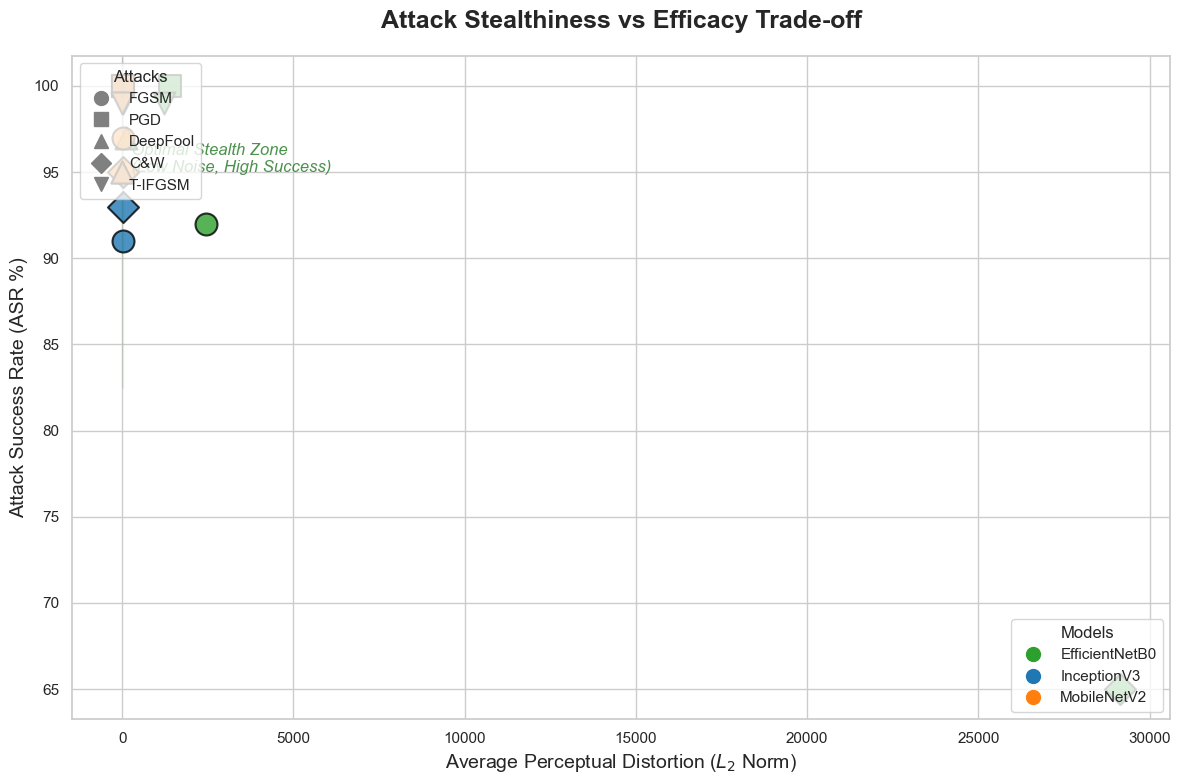

In [3]:
# Plotting
plt.figure(figsize=(12, 8))
sns.set_theme(style="whitegrid")

# Create the scatter plot
for attack in df_attacks['Attack'].unique():
    for model in df_attacks['Model'].unique():
        subset = df_attacks[(df_attacks['Attack'] == attack) & (df_attacks['Model'] == model)]
        if not subset.empty:
            plt.scatter(x=subset['Avg_L2'], 
                        y=subset['ASR (%)'], 
                        c=model_colors[model], 
                        marker=attack_markers[attack], 
                        s=250, # Marker size
                        edgecolors='black', 
                        linewidth=1.5,
                        alpha=0.8)

# Formatting and Labels
plt.title('Attack Stealthiness vs Efficacy Trade-off', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Average Perceptual Distortion ($L_2$ Norm)', fontsize=14)
plt.ylabel('Attack Success Rate (ASR %)', fontsize=14)

# Add custom legends
legend_models = [mlines.Line2D([], [], color=c, marker='o', linestyle='None', markersize=10, label=m) 
                 for m, c in model_colors.items()]
legend_attacks = [mlines.Line2D([], [], color='gray', marker=m, linestyle='None', markersize=10, label=a) 
                  for a, m in attack_markers.items()]

leg1 = plt.legend(handles=legend_models, title="Models", loc='lower right', fontsize=11, title_fontsize=12)
plt.gca().add_artist(leg1)
plt.legend(handles=legend_attacks, title="Attacks", loc='upper left', fontsize=11, title_fontsize=12)

# Highlight the "Optimal Attack Zone" (High ASR, Low L2)
plt.axvspan(0, df_attacks['Avg_L2'].median(), ymin=0.5, ymax=1, color='green', alpha=0.05)
plt.text(df_attacks['Avg_L2'].min(), 95, '  Optimal Stealth Zone\n  (Low Noise, High Success)', 
         color='darkgreen', fontsize=12, style='italic', alpha=0.7)

plt.tight_layout()
plt.show()

Interactive chart saved as 'interactive_stealthiness.html'


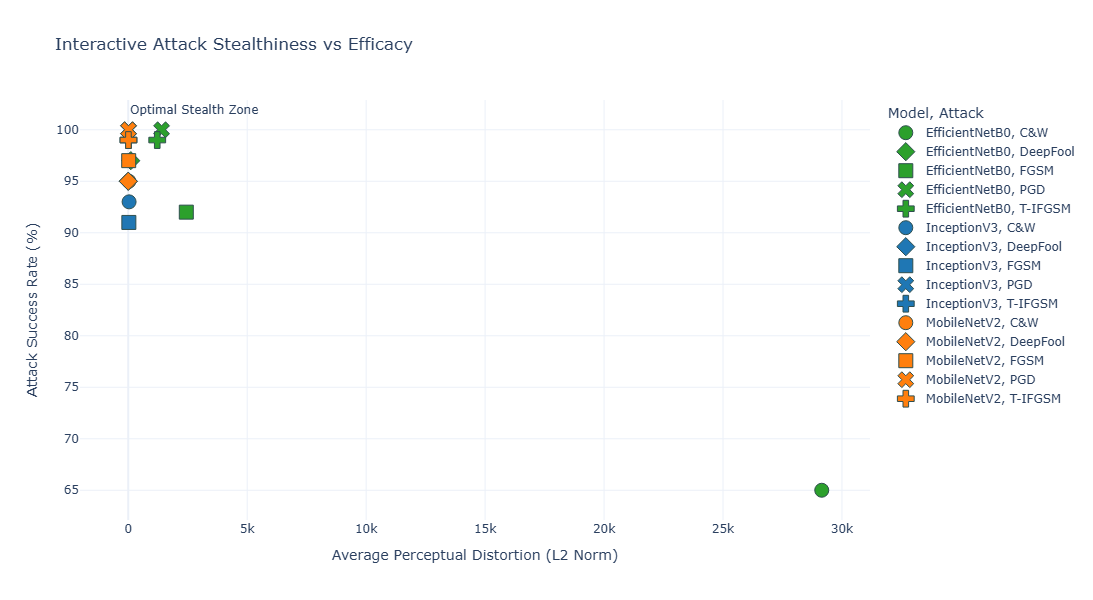

In [4]:
fig = px.scatter(
    df_attacks, 
    x="Avg_L2", 
    y="ASR (%)", 
    color="Model", 
    symbol="Attack",
    hover_data=['Model', 'Attack', 'Avg_L2', 'ASR (%)'],
    title="Interactive Attack Stealthiness vs Efficacy",
    labels={"Avg_L2": "Average Perceptual Distortion (L2 Norm)", "ASR (%)": "Attack Success Rate (%)"},
    color_discrete_map=model_colors,
    width=900, height=600
)

# Make points larger and add borders
fig.update_traces(marker=dict(size=14, line=dict(width=1, color='DarkSlateGrey')))

# Add the "Optimal Zone" background rectangle
median_l2 = df_attacks['Avg_L2'].median()
fig.add_vrect(x0=0, x1=median_l2, fillcolor="green", opacity=0.05, layer="below", line_width=0,
              annotation_text="Optimal Stealth Zone", annotation_position="top left")

fig.update_layout(template="plotly_white")

# Save as interactive HTML
html_file = "interactive_stealthiness.html"
fig.write_html(html_file)
print(f"Interactive chart saved as '{html_file}'")

# Display in notebook
fig.show()